# H.264/DASH Rate-Distortion Experiment

In this notebook, I carried out a complete rate-distortion experiment for adaptive video streaming using H.264/AVC encoded representations.

The main aim of this project was to understand how bitrate, resolution and compression quality interact when a high-quality source video is converted into multiple DASH-style streaming representations. Instead of treating encoding as a black-box process, I wanted to generate multiple versions of the same video, measure their actual bitrate and objective quality, and then use those measurements to decide which representations are most useful for adaptive streaming.

The source clip used in this experiment is a 1920×1080 cinematic video. I encoded this clip at three resolutions:

- 1920×1080
- 1280×720
- 854×480

For each resolution, I tested several target bitrates using single-pass CBR-style H.264 encoding. After encoding, I measured:

- the actual bitrate achieved by the encoder,
- the PSNR of each encoded representation,
- the rate-distortion behaviour across all encoded points.

The final output of the notebook is a set of RD curves, an upper convex hull, numerical result tables and exported files that can be used to justify bitrate-ladder decisions for adaptive streaming.


## Cell 1 — Environment Check

## 1. Environment Setup and Tool Verification

This section prepares the notebook environment and verifies that the required video-processing tools are available.

The experiment relies mainly on `ffmpeg` and `ffprobe`. `ffmpeg` is used for encoding, scaling and PSNR computation, while `ffprobe` is used to inspect video metadata and obtain technical information about the generated files.

I also import the Python libraries needed for the workflow:

- `os`, `subprocess` and `Path` for file handling and command execution,
- `json` and `re` for parsing command-line outputs,
- `numpy` and `pandas` for numerical data storage and analysis,
- `matplotlib` for plotting the RD curves.

This step is important because the rest of the notebook depends on the external FFmpeg toolchain. If FFmpeg is not available, the notebook cannot encode the representations or compute PSNR. By checking the version at the beginning, I make sure the runtime is ready before running the full experiment.


In [ ]:
import os
import re
import json
import math
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
print(result.stdout.splitlines()[0])
print("ffmpeg ready ✓")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
ffmpeg ready ✓


## 2. Uploading and Inspecting the Source Video

In this section, I upload the source video file into the notebook runtime and inspect its technical properties.

After upload, the notebook uses `ffprobe` to check important metadata such as:

- codec,
- resolution,
- frame rate,
- duration,
- pixel format.

This inspection step ensures that the file being processed is actually the expected 1080p source clip. Since the whole experiment depends on generating lower-resolution and lower-bitrate representations from this source, it is important to confirm the input properties before running the batch encoding process.

The source video acts as the master input for all later encodes. Every representation generated in the notebook is derived from this same original clip so that the RD comparison remains fair and consistent.


In [ ]:
from google.colab import files

print("Upload BvS_clip.mp4 ...")
uploaded = files.upload()
INPUT = list(uploaded.keys())[0]
print(f"Uploaded: {INPUT}")

probe = subprocess.run(
    ["ffprobe", "-v", "quiet", "-print_format", "json", "-show_streams", "-show_format", INPUT],
    capture_output=True, text=True
)
info = json.loads(probe.stdout)
vs = next(s for s in info["streams"] if s["codec_type"] == "video")

print(f"Resolution : {vs['width']}x{vs['height']}")
print(f"Codec      : {vs.get('codec_name', 'N/A')}")
print(f"Pixel fmt  : {vs.get('pix_fmt', 'N/A')}")
print(f"Frame rate : {vs.get('r_frame_rate', 'N/A')}")
print(f"Duration   : {info.get('format', {}).get('duration', vs.get('duration', 'N/A'))} s")

Upload BvS_clip.mp4 ...


Saving BvS_clip.mp4 to BvS_clip.mp4
Uploaded: BvS_clip.mp4
Resolution : 1920x1080
Codec      : h264
Pixel fmt  : yuv420p
Frame rate : 2997/125
Duration   : 20.021000 s


## 3. Defining the DASH Representation Ladder

This section defines the representation ladder used for the experiment.

I created three resolution groups:

- `1080p` at 1920×1080,
- `720p` at 1280×720,
- `480p` at 854×480.

For each resolution, I defined a list of target bitrates. Each resolution-bitrate pair represents one encoded streaming representation. Together, these points form the bitrate ladder that will later be analysed using rate-distortion curves.

The reason for testing multiple bitrates at each resolution is that the best representation is not always the highest resolution. At low bitrates, a lower-resolution encode can sometimes look better because the encoder has fewer pixels to represent. At higher bitrates, 1080p becomes more useful because enough data is available to preserve fine spatial detail.

This section also defines the output folders used by the notebook:

- `encoded/` for encoded video files,
- `references/` for PSNR reference files,
- `plots/` for RD plots and exported CSV files.

The configuration in this cell controls the full experiment. If I want to test a different bitrate ladder or a different set of resolutions, this is the main section I would modify.


In [ ]:
# Experiment setup from the assignment bitrate ladder
RESOLUTIONS = [
    {"label": "1080p", "w": 1920, "h": 1080, "bitrates_kbps": [5000, 8000, 12000, 15000, 22000]},
    {"label": "720p",  "w": 1280, "h": 720,  "bitrates_kbps": [800, 1200, 2000, 6000, 12000, 17000, 20000]},
    {"label": "480p",  "w": 854,  "h": 480,  "bitrates_kbps": [500, 750, 1200, 1800, 2400, 4800, 7200]},
]

# Choose how PSNR should be measured:
# - "upsampled_to_source": upscale each encoded file to 1080p and compare with the 1080p reference
# - "same_resolution": compare each encode to a reference at the same resolution
PSNR_MODE = "upsampled_to_source"

# Plotting / hull settings
PLOT_LOG_X = False          # keep False so the hull is computed and displayed in the same bitrate domain
HULL_X_DOMAIN = "linear"    # "linear" recommended here

COLORS = {"1080p": "#2ca02c", "720p": "#ff7f0e", "480p": "#1f77b4"}

OUT_DIR = Path("encoded")
REF_DIR = Path("references")
PLOT_DIR = Path("plots")

OUT_DIR.mkdir(exist_ok=True)
REF_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)

total = sum(len(r["bitrates_kbps"]) for r in RESOLUTIONS)
print("Configuration set ✓")
print(f"PSNR_MODE   = {PSNR_MODE}")
print(f"PLOT_LOG_X  = {PLOT_LOG_X}")
print(f"Total encodes to run: {total}")

Configuration set ✓
PSNR_MODE   = upsampled_to_source
PLOT_LOG_X  = False
Total encodes to run: 19


## 4. Creating the Reference Video for PSNR Measurement

This section creates the reference file used for objective quality measurement.

PSNR compares a compressed/distorted video against a reference. For this experiment, I create a high-quality 1920×1080 reference using FFmpeg. The source is scaled to 1920×1080 and encoded in a lossless or near-lossless H.264 format using `libx264` with `crf=0`.

Creating a controlled reference file is useful because it ensures that all later comparisons use a consistent pixel format and resolution. This reduces the chance of format mismatch problems during PSNR computation.

In this notebook, I use the `upsampled_to_source` PSNR mode. This means that every encoded representation, including 720p and 480p, is upscaled back to 1920×1080 before being compared against the 1080p reference. This makes the comparison display-oriented because all encoded outputs are evaluated at the same final viewing resolution.

The notebook also avoids rebuilding the reference if it already exists. This caching makes repeated runs faster.


In [ ]:
REF_1080P = REF_DIR / "ref_1920x1080_lossless_yuv420p.mp4"

def build_lossless_reference(input_path, out_path, w=None, h=None):
    vf = []
    if w is not None and h is not None:
        vf.append(f"scale={w}:{h}:flags=lanczos")
    vf.append("format=yuv420p")
    cmd = [
        "ffmpeg", "-y", "-i", input_path,
        "-vf", ",".join(vf),
        "-c:v", "libx264", "-crf", "0", "-preset", "ultrafast",
        "-an", str(out_path)
    ]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(r.stderr[-3000:])

if not REF_1080P.exists():
    print("Building shared 1080p reference ...")
    build_lossless_reference(INPUT, REF_1080P, 1920, 1080)
else:
    print(f"Using cached reference: {REF_1080P}")

for spec in RESOLUTIONS:
    spec["ref_path_1080"] = str(REF_1080P)

if PSNR_MODE == "same_resolution":
    for spec in RESOLUTIONS:
        ref_path = REF_DIR / f"ref_{spec['w']}x{spec['h']}_lossless_yuv420p.mp4"
        if not ref_path.exists():
            print(f"Building same-resolution reference for {spec['label']} ...")
            build_lossless_reference(INPUT, ref_path, spec["w"], spec["h"])
        spec["ref_path_same"] = str(ref_path)

print("Reference setup complete ✓")

Building shared 1080p reference ...
Reference setup complete ✓


## Encode All Representations (single-pass CBR H.264)

## 5. Encoding the H.264 Representations

This section performs the main encoding stage of the experiment.

For every resolution and target bitrate defined in the representation ladder, the notebook generates one encoded H.264 video. The encoding is done using FFmpeg with `libx264`.

The important encoding choices are:

- scaling to the target resolution,
- using H.264/AVC through `libx264`,
- using `yuv420p` for compatibility,
- using single-pass CBR-style encoding,
- setting the target bitrate, minimum bitrate and maximum bitrate,
- using a buffer size proportional to the target bitrate,
- forcing constant frame rate behaviour.

Each encoded file corresponds to one RD point. For example, one point might represent 720p at 6000 kbps, while another might represent 480p at 1200 kbps.

The notebook prints progress while encoding and reuses existing files if they have already been generated. This is useful because encoding several representations can take time, and caching avoids unnecessary repeated computation.

This stage converts the theoretical bitrate ladder into real encoded video files that can then be measured and compared.


In [ ]:
def encode_cbr_h264(input_path, out_path, w, h, bitrate_kbps):
    if os.path.exists(out_path):
        return True, "cached"

    cmd = [
        "ffmpeg", "-y", "-i", input_path,
        "-vf", f"scale={w}:{h}:flags=lanczos,format=yuv420p",
        "-c:v", "libx264",
        "-preset", "medium",
        "-b:v", f"{bitrate_kbps}k",
        "-minrate", f"{bitrate_kbps}k",
        "-maxrate", f"{bitrate_kbps}k",
        "-bufsize", f"{2 * bitrate_kbps}k",
        "-x264-params", "nal-hrd=cbr:force-cfr=1",
        "-an",
        str(out_path),
    ]
    r = subprocess.run(cmd, capture_output=True, text=True)
    return r.returncode == 0, r.stderr

done = 0
for spec in RESOLUTIONS:
    spec["encoded_paths"] = []
    for bitrate_kbps in spec["bitrates_kbps"]:
        out_path = OUT_DIR / f"{spec['label']}_{bitrate_kbps}k.mp4"
        ok, msg = encode_cbr_h264(INPUT, out_path, spec["w"], spec["h"], bitrate_kbps)
        done += 1
        tag = "cached" if msg == "cached" else ("ok" if ok else "FAIL")
        print(f"[{done:2d}/{total}] {spec['label']:>5} @ {bitrate_kbps:>5d} kbps  {'✓' if ok else '✗'}  ({tag})")
        if not ok:
            print(msg[-1200:])
        spec["encoded_paths"].append(str(out_path) if ok else None)

print("\nAll encodes complete ✓")

[ 1/19] 1080p @  5000 kbps  ✓  (ok)
[ 2/19] 1080p @  8000 kbps  ✓  (ok)
[ 3/19] 1080p @ 12000 kbps  ✓  (ok)
[ 4/19] 1080p @ 15000 kbps  ✓  (ok)
[ 5/19] 1080p @ 22000 kbps  ✓  (ok)
[ 6/19]  720p @   800 kbps  ✓  (ok)
[ 7/19]  720p @  1200 kbps  ✓  (ok)
[ 8/19]  720p @  2000 kbps  ✓  (ok)
[ 9/19]  720p @  6000 kbps  ✓  (ok)
[10/19]  720p @ 12000 kbps  ✓  (ok)
[11/19]  720p @ 17000 kbps  ✓  (ok)
[12/19]  720p @ 20000 kbps  ✓  (ok)
[13/19]  480p @   500 kbps  ✓  (ok)
[14/19]  480p @   750 kbps  ✓  (ok)
[15/19]  480p @  1200 kbps  ✓  (ok)
[16/19]  480p @  1800 kbps  ✓  (ok)
[17/19]  480p @  2400 kbps  ✓  (ok)
[18/19]  480p @  4800 kbps  ✓  (ok)
[19/19]  480p @  7200 kbps  ✓  (ok)

All encodes complete ✓


## 6. Measuring Actual Bitrate and PSNR

This section measures the two values needed for rate-distortion analysis:

- rate, measured as actual bitrate,
- distortion or quality, measured using PSNR.

Although each encode is given a target bitrate, the final encoded file may not exactly match that target. Encoder behaviour, file headers, buffering and content complexity can cause small differences between target bitrate and achieved bitrate. Therefore, I measure the actual bitrate from the encoded file rather than assuming the target bitrate is exact.

The actual bitrate is calculated from the file size and duration:

```text
actual bitrate = file size in bits / duration
````

For PSNR, the notebook uses FFmpeg’s `psnr` filter. Since I use `upsampled_to_source` mode, each encoded video is first upscaled to 1920×1080 and then compared against the 1080p reference.

For every encoded representation, the notebook stores:

* representation label,
* width,
* height,
* target bitrate,
* actual bitrate,
* PSNR,
* encoded file path.

These results are collected into a Pandas DataFrame and saved as a CSV file. This table becomes the main numerical result of the experiment.


In [ ]:
def parse_average_psnr(text):
    matches = re.findall(r"average:([0-9]+\.?[0-9]*|inf)", text)
    if not matches:
        raise RuntimeError("Could not parse PSNR from ffmpeg output:\n" + text[:4000])
    val = matches[-1]
    return float("inf") if val == "inf" else float(val)

def measure_psnr(encoded_path, ref_path, mode, w=None, h=None):
    if mode == "upsampled_to_source":
        lavfi = (
            "[0:v]scale=1920:1080:flags=lanczos,format=yuv420p[dist];"
            "[1:v]format=yuv420p[ref];"
            "[dist][ref]psnr"
        )
    elif mode == "same_resolution":
        if w is None or h is None:
            raise ValueError("w and h are required for same_resolution PSNR mode")
        lavfi = (
            f"[0:v]format=yuv420p[dist];"
            f"[1:v]scale={w}:{h}:flags=lanczos,format=yuv420p[ref];"
            "[dist][ref]psnr"
        )
    else:
        raise ValueError(f"Unknown PSNR mode: {mode}")

    cmd = [
        "ffmpeg", "-y",
        "-i", encoded_path,
        "-i", ref_path,
        "-lavfi", lavfi,
        "-f", "null", "-"
    ]
    r = subprocess.run(cmd, capture_output=True, text=True)
    return parse_average_psnr((r.stderr or "") + "\n" + (r.stdout or ""))

def measure_actual_bitrate_kbps(encoded_path):
    probe = subprocess.run(
        ["ffprobe", "-v", "quiet", "-print_format", "json", "-show_format", "-show_streams", encoded_path],
        capture_output=True, text=True
    )
    info = json.loads(probe.stdout)
    duration = float(info["format"]["duration"])
    size_bytes = int(info["format"]["size"])
    return (size_bytes * 8.0) / duration / 1000.0

rows = []

print(f"{'Resolution':<10} {'Target':>10} {'Actual':>10} {'PSNR':>10}")
print("─" * 46)

for spec in RESOLUTIONS:
    spec["results"] = []
    for bitrate_kbps, enc_path in zip(spec["bitrates_kbps"], spec["encoded_paths"]):
        if enc_path is None or not os.path.exists(enc_path):
            print(f"{spec['label']:<10} {bitrate_kbps:>10} {'MISSING':>10} {'-':>10}")
            continue

        ref_path = spec["ref_path_1080"] if PSNR_MODE == "upsampled_to_source" else spec["ref_path_same"]
        actual_kbps = measure_actual_bitrate_kbps(enc_path)
        psnr_db = measure_psnr(enc_path, ref_path, PSNR_MODE, spec["w"], spec["h"])

        spec["results"].append((actual_kbps, psnr_db))
        rows.append({
            "label": spec["label"],
            "width": spec["w"],
            "height": spec["h"],
            "target_bitrate_kbps": bitrate_kbps,
            "actual_bitrate_kbps": actual_kbps,
            "psnr_db": psnr_db,
            "psnr_mode": PSNR_MODE,
            "file": enc_path,
        })

        print(f"{spec['label']:<10} {bitrate_kbps:>10} {actual_kbps:>10.1f} {psnr_db:>10.3f}")

df = pd.DataFrame(rows).sort_values(["actual_bitrate_kbps", "psnr_db"]).reset_index(drop=True)
csv_path = PLOT_DIR / "rd_results.csv"
df.to_csv(csv_path, index=False)

print("\nMeasurements complete ✓")
print("Saved:", csv_path)
df

Resolution     Target     Actual       PSNR
──────────────────────────────────────────────
1080p            5000     5147.4     40.626
1080p            8000     8210.9     41.161
1080p           12000    12298.4     41.837
1080p           15000    15391.7     42.323
1080p           22000    22524.6     43.373
720p              800      817.7     38.474
720p             1200     1225.8     39.322
720p             2000     2045.9     39.953
720p             6000     6143.6     40.927
720p            12000    12236.5     41.787
720p            17000    17314.0     42.293
720p            20000    20359.8     42.524
480p              500      511.0     37.682
480p              750      765.8     38.561
480p             1200     1225.9     39.256
480p             1800     1839.4     39.652
480p             2400     2452.2     39.874
480p             4800     4888.5     40.386
480p             7200     7309.4     40.693

Measurements complete ✓
Saved: plots/rd_results.csv


,label,width,height,target_bitrate_kbps,actual_bitrate_kbps,psnr_db,psnr_mode,file
0,480p,854,480,500,510.988662,37.681522,upsampled_to_source,encoded/480p_500k.mp4
1,480p,854,480,750,765.836671,38.560768,upsampled_to_source,encoded/480p_750k.mp4
2,720p,1280,720,800,817.740572,38.473575,upsampled_to_source,encoded/720p_800k.mp4
3,720p,1280,720,1200,1225.761750,39.321594,upsampled_to_source,encoded/720p_1200k.mp4
4,480p,854,480,1200,1225.863244,39.255627,upsampled_to_source,encoded/480p_1200k.mp4
5,480p,854,480,1800,1839.436592,39.651556,upsampled_to_source,encoded/480p_1800k.mp4
6,720p,1280,720,2000,2045.870236,39.953467,upsampled_to_source,encoded/720p_2000k.mp4
7,480p,854,480,2400,2452.184007,39.873966,upsampled_to_source,encoded/480p_2400k.mp4
8,480p,854,480,4800,4888.521452,40.385849,upsampled_to_source,encoded/480p_4800k.mp4
9,1080p,1920,1080,5000,5147.445183,40.625803,upsampled_to_source,encoded/1080p_5000k.mp4


## Cell 7 — Pareto Frontier + Upper Hull

This section collects all measured values into a structured RD dataset.

Each row of the dataset represents one encoded video. The key columns are:

- `label`: the representation group such as 480p, 720p or 1080p,
- `width` and `height`: the encoded resolution,
- `target_kbps`: the bitrate requested during encoding,
- `actual_kbps`: the bitrate actually achieved,
- `psnr`: the measured objective quality,
- `path`: the location of the encoded file.

This dataset is important because it allows the experiment to be analysed numerically rather than only visually. Once all RD points are stored in a table, I can sort them, plot them, compute efficient points and export the results.

The measured data also shows the practical behaviour of the encoder. Even with CBR-style settings, the actual bitrate can differ slightly from the target, which is why using measured bitrate gives a more accurate RD curve.

A representation is considered dominated if another representation provides equal or better PSNR at equal or lower bitrate. Dominated points are not very useful for adaptive streaming because a better or equally good option already exists at the same or lower rate.

To compute the Pareto frontier, I sort all encoded points by actual bitrate. Then I keep only the points that improve on the best PSNR seen so far. This produces a set of candidate representations where each selected point provides a genuine quality improvement.

The Pareto frontier is useful because it filters the raw experiment results and focuses attention on the representations that are actually competitive.


In [ ]:
def pareto_frontier(df_in):
    # Keep points that are not dominated by another point with lower/equal bitrate and higher/equal PSNR
    rows = (
        df_in[["label", "width", "height", "target_bitrate_kbps", "actual_bitrate_kbps", "psnr_db"]]
        .sort_values(["actual_bitrate_kbps", "psnr_db"], ascending=[True, False])
        .to_dict("records")
    )
    frontier = []
    best_psnr = -float("inf")
    for row in rows:
        if row["psnr_db"] > best_psnr + 1e-12:
            frontier.append(row)
            best_psnr = row["psnr_db"]
    return frontier

def upper_concave_hull(frontier_rows, x_domain="linear"):
    def tx(x):
        return math.log10(x) if x_domain == "log" else x

    hull = []
    for row in sorted(frontier_rows, key=lambda r: (r["actual_bitrate_kbps"], r["psnr_db"])):
        while len(hull) >= 2:
            o = hull[-2]
            a = hull[-1]
            cross = (
                (tx(a["actual_bitrate_kbps"]) - tx(o["actual_bitrate_kbps"])) * (row["psnr_db"] - o["psnr_db"])
                - (a["psnr_db"] - o["psnr_db"]) * (tx(row["actual_bitrate_kbps"]) - tx(o["actual_bitrate_kbps"]))
            )
            # For the upper concave hull we want slopes to decrease as bitrate increases.
            # If cross >= 0, the middle point is not on the upper hull.
            if cross >= -1e-12:
                hull.pop()
            else:
                break
        hull.append(row)
    return hull

frontier_rows = pareto_frontier(df)
hull_rows = upper_concave_hull(frontier_rows, x_domain=HULL_X_DOMAIN)

frontier_df = pd.DataFrame(frontier_rows)
hull_df = pd.DataFrame(hull_rows)

print("Pareto frontier points:")
display(frontier_df)

print("Upper hull points:")
display(hull_df)

Pareto frontier points:


,label,width,height,target_bitrate_kbps,actual_bitrate_kbps,psnr_db
0,480p,854,480,500,510.988662,37.681522
1,480p,854,480,750,765.836671,38.560768
2,720p,1280,720,1200,1225.761750,39.321594
3,480p,854,480,1800,1839.436592,39.651556
4,720p,1280,720,2000,2045.870236,39.953467
5,480p,854,480,4800,4888.521452,40.385849
6,1080p,1920,1080,5000,5147.445183,40.625803
7,720p,1280,720,6000,6143.605215,40.926785
8,1080p,1920,1080,8000,8210.896559,41.160789
9,720p,1280,720,12000,12236.478098,41.787484


Upper hull points:


,label,width,height,target_bitrate_kbps,actual_bitrate_kbps,psnr_db
0,480p,854,480,500,510.988662,37.681522
1,480p,854,480,750,765.836671,38.560768
2,720p,1280,720,1200,1225.761750,39.321594
3,720p,1280,720,2000,2045.870236,39.953467
4,720p,1280,720,6000,6143.605215,40.926785
5,1080p,1920,1080,15000,15391.671545,42.322642
6,1080p,1920,1080,22000,22524.643524,43.372698


## Cell 8 — Plot RD Curves and Upper Hull

## 9. Computing the Upper Convex Hull

This section computes the upper hull of the RD points.

The upper hull represents the outer boundary of the best rate-distortion trade-offs. In the context of adaptive streaming, the hull points are especially important because they indicate which representations are most efficient for bitrate-ladder design.

The notebook uses a geometric cross-product check to remove points that do not lie on the upper boundary. This gives a cleaner set of candidate encodes than simply looking at all measured results.

The upper hull helps answer an important practical question:

> If I can only choose a limited number of representations, which bitrate-resolution combinations give the strongest quality improvement for their bitrate?

This is useful because a real streaming ladder should not include every possible encode. It should include a compact set of efficient representations.

This section also plots PSNR against actual bitrate for each resolution group:

- 480p,
- 720p,
- 1080p.

Each curve shows how quality changes as bitrate increases for that resolution. The x-axis represents actual bitrate in kbps, while the y-axis represents PSNR in dB.

The upper hull is plotted on the same figure using a highlighted line. This makes it easy to see which representations are efficient and which points lie below the best trade-off boundary.

This plot is one of the most important outputs of the project because it summarises the behaviour of all encoded representations in a single figure. It shows:

- how quality improves with bitrate,
- where diminishing returns appear,
- when lower resolutions are more efficient,
- when higher resolutions become worthwhile,
- which points are strongest candidates for adaptive streaming.




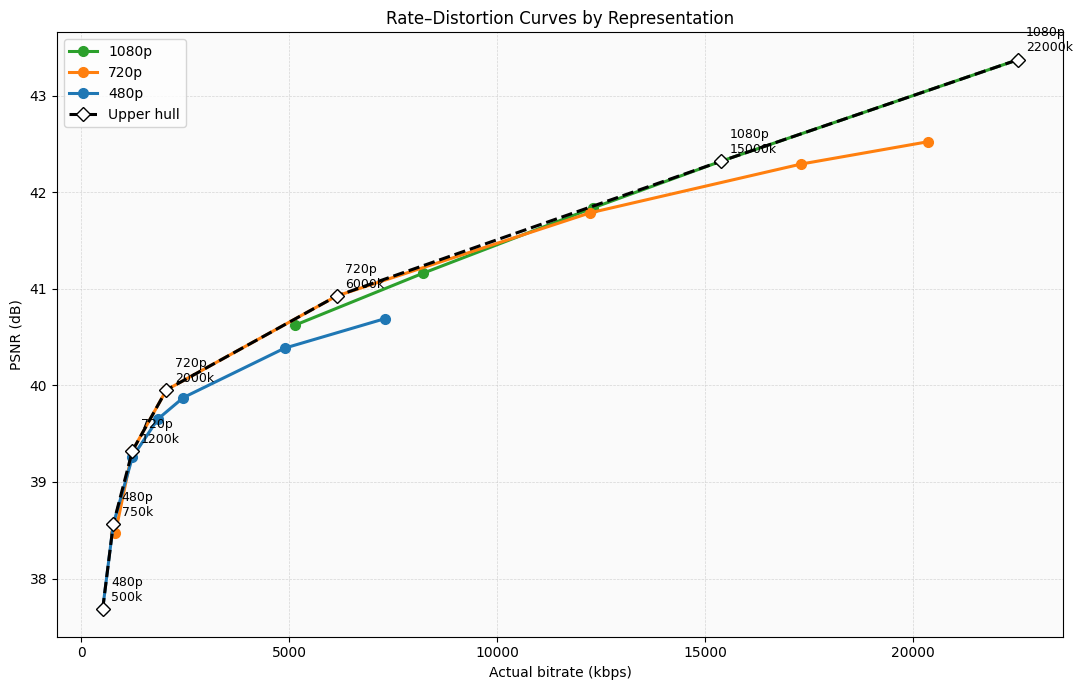

Saved: plots/rd_curves_with_hull.png
Saved: plots/rd_curves_with_hull.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#fafafa")
ax.grid(True, linestyle="--", linewidth=0.5, color="#cccccc", alpha=0.8)

for spec in RESOLUTIONS:
    sub = df[df["label"] == spec["label"]].sort_values("actual_bitrate_kbps")
    ax.plot(
        sub["actual_bitrate_kbps"], sub["psnr_db"],
        color=COLORS[spec["label"]], marker="o", linewidth=2.2, markersize=7,
        label=spec["label"], zorder=3
    )

if len(hull_df) > 0:
    ax.plot(
        hull_df["actual_bitrate_kbps"], hull_df["psnr_db"],
        color="black", linestyle="--", linewidth=2.2,
        marker="D", markersize=7, markerfacecolor="white",
        label="Upper hull", zorder=4
    )

    for _, row in hull_df.iterrows():
        ax.annotate(
            f"{row['label']}\n{row['target_bitrate_kbps']}k",
            (row["actual_bitrate_kbps"], row["psnr_db"]),
            textcoords="offset points", xytext=(6, 6), fontsize=9
        )

if PLOT_LOG_X:
    ax.set_xscale("log")

ax.set_xlabel("Actual bitrate (kbps)")
ax.set_ylabel("PSNR (dB)")
ax.set_title("Rate–Distortion Curves by Representation")
ax.legend()

plt.tight_layout()

plot_png = PLOT_DIR / "rd_curves_with_hull.png"
plot_pdf = PLOT_DIR / "rd_curves_with_hull.pdf"
plt.savefig(plot_png, dpi=200, bbox_inches="tight")
plt.savefig(plot_pdf, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_png)
print("Saved:", plot_pdf)

## 11. Final RD Tables

This section prints the final numerical tables from the experiment.

The first table contains all encoded representations, sorted by resolution and bitrate. It gives the measured bitrate and PSNR for every encode.

The second table contains the upper hull candidates. These are the most important points for representation selection because they provide the best quality-rate trade-offs.

The tables are useful because the plot shows the trend visually, but the tables provide the exact values needed for decision-making. For example, I can directly compare how much PSNR improvement is gained by increasing bitrate from one point to another.

This helps identify where additional bitrate gives meaningful quality improvement and where it gives only small returns.


In [ ]:
print(f"{'Resolution':<10} {'Target (kbps)':>14} {'Actual (kbps)':>14} {'PSNR (dB)':>12}")
print("═" * 56)
for _, row in df.sort_values(["width", "actual_bitrate_kbps"], ascending=[False, True]).iterrows():
    print(f"{row['label']:<10} {int(row['target_bitrate_kbps']):>14} {row['actual_bitrate_kbps']:>14.1f} {row['psnr_db']:>12.3f}")

print("\nUpper hull candidates:")
print(f"{'Resolution':<10} {'Target (kbps)':>14} {'Actual (kbps)':>14} {'PSNR (dB)':>12}")
print("─" * 56)
for _, row in hull_df.iterrows():
    print(f"{row['label']:<10} {int(row['target_bitrate_kbps']):>14} {row['actual_bitrate_kbps']:>14.1f} {row['psnr_db']:>12.3f}")

Resolution  Target (kbps)  Actual (kbps)    PSNR (dB)
════════════════════════════════════════════════════════
1080p                5000         5147.4       40.626
1080p                8000         8210.9       41.161
1080p               12000        12298.4       41.837
1080p               15000        15391.7       42.323
1080p               22000        22524.6       43.373
720p                  800          817.7       38.474
720p                 1200         1225.8       39.322
720p                 2000         2045.9       39.953
720p                 6000         6143.6       40.927
720p                12000        12236.5       41.787
720p                17000        17314.0       42.293
720p                20000        20359.8       42.524
480p                  500          511.0       37.682
480p                  750          765.8       38.561
480p                 1200         1225.9       39.256
480p                 1800         1839.4       39.652
480p                 2400

## Cell 10 — Download Outputs

In [ ]:
from google.colab import files

for path in [csv_path, plot_png, plot_pdf]:
    if os.path.exists(path):
        files.download(str(path))
        print("Downloaded", path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded plots/rd_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded plots/rd_curves_with_hull.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded plots/rd_curves_with_hull.pdf
